# Module 2 — First DFT Calculations: Molecular Bonding (O₂ and CO)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YOUR-GITHUB-USERNAME/qe-dft-course/blob/main/02_molecule_dft.ipynb)

Run your first real Quantum ESPRESSO calculations: find the equilibrium bond length of CO by scanning bond lengths by hand, estimate a vibrational frequency, look at Kohn–Sham energy levels, and see O₂'s unpaired electrons show up directly in the calculation.

**Learning objectives**
- Set up and run a QE self-consistent field (SCF) calculation from ASE
- Find an equilibrium bond length by scanning energy vs. geometry
- Estimate a vibrational frequency from the curvature of that scan
- Read out Kohn–Sham eigenvalues as a HOMO–LUMO level diagram
- See that O₂'s DFT ground state has **2 unpaired electrons**, unlike its textbook Lewis structure


## Setup: installing Quantum ESPRESSO

We first install Quantum ESPRESSO (QE) DFT package using **Ubuntu's own package repository** (`apt`) rather than conda.

In [1]:
!apt-get update -qq
!apt-get install -qq -y quantum-espresso
!pip install -q ase==3.23.0


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package libfftw3-double3:amd64.
(Reading database ... 118419 files and directories currently installed.)
Preparing to unpack .../libfftw3-double3_3.3.8-2ubuntu8_amd64.deb ...
Unpacking libfftw3-double3:amd64 (3.3.8-2ubuntu8) ...
Selecting previously unselected package quantum-espresso.
Preparing to unpack .../quantum-espresso_6.7-2build1_amd64.deb ...
Unpacking quantum-espresso (6.7-2build1) ...
Selecting previously unselected package quantum-espresso-data.
Preparing to unpack .../quantum-espresso-data_6.7-2build1_all.deb ...
Unpacking quantum-espresso-data (6.7-2build1) ...
Setting up quantum-espresso-data (6.7-2build1) ...
Setting up libfftw3-double3:amd64 (3.3.8-2ubuntu8) ...
Setting up quantum-espresso (6.7-2build1) ...
Processing triggers for libc-bin (2.35-0ubunt

In [2]:
# Quick sanity check before going any further: confirm pw.x (a system
# binary from apt) and ase (a Python package from pip) are both reachable.
!which pw.x
!which projwfc.x
import ase
print('ase', ase.__version__, '->', ase.__file__)


/usr/bin/pw.x
/usr/bin/projwfc.x
ase 3.23.0 -> /usr/local/lib/python3.13/dist-packages/ase/__init__.py


In [3]:
from ase.calculators.espresso import EspressoProfile

# ASE need to be configured to recognize installed QE. For this EspressoProfile
# profile object need to be configured. This tells
# ASE how to launch pw.x, and where to find the pseudopotential files we
# download below. We build this ONE profile object and reuse it for every
# Espresso(...) calculator in this notebook.
profile = EspressoProfile(command='pw.x', pseudo_dir='pseudo')


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from ase import Atoms
from ase.calculators.espresso import Espresso

plt.rcParams['figure.dpi'] = 110


### Getting pseudopotentials (GBRV library)

Quantum ESPRESSO needs a pseudopotential file (`.UPF`) for every element in the calculation. We use the **GBRV library** (Garrity, Bennett, Rabe & Vanderbilt, *Comput. Mater. Sci.* 81, 446 (2014)) — a comprehensive, well-tested ultrasoft pseudopotential set designed around a single uniform plane-wave cutoff. We download the whole library once, keep only the files we need, and rename them from GBRV's own naming convention (e.g. `o_pbe_v1.2.uspp.F.UPF`) to the simple `O.UPF` that ASE/QE expect.

In [5]:
# Download and unpack the GBRV pseudopotential library, then rename each
# file from GBRV's convention (e.g. 'o_pbe_v1.2.uspp.F.UPF') to the plain
# 'O.UPF' that ASE/QE expect. NOTE: keep this wget on a single line --
# splitting a quoted URL across a '!'-prefixed line with a trailing
# backslash does NOT reliably concatenate in Colab and silently breaks
# into two separate (broken) URLs.
!mkdir -p pseudo
!wget -q -O gbrv.tar.gz https://www.physics.rutgers.edu/gbrv/all_pbe_UPF_v1.5.tar.gz
!tar -xzf gbrv.tar.gz -C pseudo

import glob, os, shutil

for f in glob.glob('pseudo/*_*.UPF'):
    new_name = os.path.basename(f).split('_')[0].capitalize() + '.UPF'
    shutil.move(f, os.path.join('pseudo', new_name))

# We only actually need a few elements here: O and C
print(sorted(glob.glob('pseudo/*.UPF'))[:10], '...')


['pseudo/Ag.UPF', 'pseudo/Al.UPF', 'pseudo/As.UPF', 'pseudo/Au.UPF', 'pseudo/B.UPF', 'pseudo/Ba.UPF', 'pseudo/Be.UPF', 'pseudo/Bi.UPF', 'pseudo/Br.UPF', 'pseudo/C.UPF'] ...


GBRV renames cleanly to `Element.UPF`, and the whole library is designed around one uniform recommended cutoff rather than a per-element table — so our helper functions below are simpler as compared to other pseudopotential styles (say SSSP-style pseudopotential which require per-element JSON lookup).

In [6]:
def pseudo_filename(symbol):
    return f'{symbol}.UPF'

def recommended_cutoffs(symbol):
    """GBRV is designed around one uniform cutoff rather than per-element
    values: ~40 Ry for ecutwfc, and since these are ultrasoft
    pseudopotentials, ecutrho should be 8-12x that (we use 8x)."""
    return 40, 320


In [8]:
for el in ['O', 'C']:
    fn = pseudo_filename(el)
    ecutwfc, ecutrho = recommended_cutoffs(el)
    print(f'{el}: {fn}  (recommended ecutwfc={ecutwfc} Ry, ecutrho={ecutrho} Ry)')


O: O.UPF  (recommended ecutwfc=40 Ry, ecutrho=320 Ry)
C: C.UPF  (recommended ecutwfc=40 Ry, ecutrho=320 Ry)


## Part 1 — A molecule in a box

Quantum ESPRESSO is a **plane-wave, periodic** code — it always applies periodic boundary conditions, even to a single molecule. To simulate an isolated CO molecule, we put it at the center of a large cubic box of empty space ("vacuum"). We'll come back to *why* the box size matters in the question below, once you've seen the setup.

In [9]:
def make_boxed_molecule(symbols, positions, box=12.0):
    """Put a small molecule at the center of a cubic vacuum box."""
    atoms = Atoms(symbols, positions=positions)
    atoms.set_cell([box, box, box])
    atoms.center()
    atoms.pbc = True  # QE always requires this, even for a 'molecule'
    return atoms

co = make_boxed_molecule(['C', 'O'], [[0, 0, 0], [0, 0, 1.13]])
print(co)


Atoms(symbols='CO', pbc=True, cell=[12.0, 12.0, 12.0])


A quick 3D look before we run anything — notice how much empty space surrounds the molecule.

In [10]:
from ase.visualize import view

view(co, viewer='x3d')  # drag to rotate, scroll to zoom


In [11]:
pseudopotentials = {'C': pseudo_filename('C'), 'O': pseudo_filename('O')}

input_data = {
    'control': {'calculation': 'scf', 'pseudo_dir': 'pseudo', 'outdir': 'out'},
    'system': {'ecutwfc': 40, 'ecutrho': 320, 'occupations': 'fixed'},
    'electrons': {'conv_thr': 1.0e-8},
}


In [12]:
co.calc = Espresso(profile=profile, pseudopotentials=pseudopotentials, input_data=input_data,
                    kpts=(1, 1, 1))  # a single (Gamma) k-point is enough for a big vacuum box
energy = co.get_potential_energy()
print(f'CO total energy: {energy:.4f} eV')


CO total energy: -594.4320 eV


### A quick note on units: Ry vs. eV

QE's *input* parameters — `ecutwfc`, `ecutrho`,
`degauss` — are all in **Rydberg (Ry)**, QE's native energy unit, while ASE functions work in **eV**. ASE converts them from Ry to eV automatically.

In [16]:
import scipy.constants as sc

ry_to_ev = sc.value('Rydberg constant times hc in eV')
print(f'1 Ry = {ry_to_ev:.4f} eV')
print(f'1 Hartree (= 2 Ry) = {2 * ry_to_ev:.4f} eV')

# Example: our ecutwfc of 40 Ry, in eV
ecutwfc_ry = 40
print(f'\necutwfc = {ecutwfc_ry} Ry = {ecutwfc_ry * ry_to_ev:.1f} eV')

1 Ry = 13.6057 eV
1 Hartree (= 2 Ry) = 27.2114 eV

ecutwfc = 40 Ry = 544.2 eV


### A first look at what QE actually wrote to disk

That single `get_potential_energy()` call just created several files in your Colab session's working directory (`espresso.pwi`, `espresso.pwo`, and an `out/` folder) — you can browse them yourself using the folder icon in Colab's left sidebar, or read them directly here. `.pwi` is what we *sent* QE; `.pwo` is what QE *wrote back*. Worth reading these.

In [13]:
!ls -la
!echo '--- espresso.pwi (what we asked QE to do) ---'
!cat espresso.pwi


total 12792
drwxr-xr-x 1 root root     4096 Aug 27 10:10 .
drwxr-xr-x 1 root root     4096 Aug 27 09:28 ..
drwxr-xr-x 4 root root     4096 Aug 24 13:21 .config
-rw-r--r-- 1 root root        0 Aug 27 10:10 espresso.err
-rw-r--r-- 1 root root      707 Aug 27 10:10 espresso.pwi
-rw-r--r-- 1 root root    10913 Aug 27 10:12 espresso.pwo
-rw-r--r-- 1 root root 13057180 Jun  6  2017 gbrv.tar.gz
drwxr-xr-x 3 root root     4096 Aug 27 10:12 out
drwxr-xr-x 2 root root     4096 Aug 27 09:48 pseudo
drwxr-xr-x 1 root root     4096 Aug 24 13:21 sample_data
--- espresso.pwi (what we asked QE to do) ---
&CONTROL
   calculation      = 'scf'
   outdir           = 'out'
   pseudo_dir       = 'pseudo'
/
&SYSTEM
   ecutwfc          = 40
   ecutrho          = 320
   occupations      = 'fixed'
   ntyp             = 2
   nat              = 2
   ibrav            = 0
/
&ELECTRONS
   conv_thr         = 1e-08
/
&IONS
/
&CELL
/
&FCP
/
&RISM
/
ATOMIC_SPECIES
C 12.011 C.UPF
O 15.999 O.UPF

K_POINTS automatic
1 1 1  

A few things worth finding in that input file yourself: the `&SYSTEM` block (cutoffs, occupations), the `ATOMIC_SPECIES` card (which pseudopotential file got used), the `K_POINTS` card, and the `ATOMIC_POSITIONS`/`CELL_PARAMETERS` cards (your 12 Å box).

Now the output file — this is much longer, so we'll grep for a few key sections rather than dumping the whole thing:

In [14]:
!echo '--- SCF iterations (watch the total energy converge) ---'
!grep -A1 'total energy' espresso.pwo | head -20
!echo
!echo '--- did it actually converge? ---'
!grep -i 'convergence has been achieved' espresso.pwo
!echo
!echo '--- Kohn-Sham eigenvalues QE computed ---'
!grep -A3 'bands (ev)' espresso.pwo | head -8


--- SCF iterations (watch the total energy converge) ---
     total energy              =     -43.60637115 Ry
     estimated scf accuracy    <       0.21741817 Ry
--
     total energy              =     -43.59265503 Ry
     estimated scf accuracy    <       0.47696952 Ry
--
     total energy              =     -43.68897556 Ry
     estimated scf accuracy    <       0.00820383 Ry
--
     total energy              =     -43.68935333 Ry
     estimated scf accuracy    <       0.00253752 Ry
--
     total energy              =     -43.68990411 Ry
     estimated scf accuracy    <       0.00001303 Ry
--
     total energy              =     -43.68994075 Ry
     estimated scf accuracy    <       0.00018706 Ry
--
     total energy              =     -43.68994751 Ry
     estimated scf accuracy    <       0.00002581 Ry

--- did it actually converge? ---
     convergence has been achieved in   9 iterations

--- Kohn-Sham eigenvalues QE computed ---
          k = 0.0000 0.0000 0.0000 ( 49941 PWs)   ba

Open `espresso.pwo` yourself (double-click it in Colab's file browser, or scroll through the `!cat` output from Part 1). Check how many SCF iterations did it take to converge?

## Part 2 — Finding the equilibrium bond length of CO

We compute the energy at several C–O separations and look for the minimum.

In [ ]:
bond_lengths = np.arange(1.00, 1.41, 0.05)  # Angstrom
co_energies = []

for d in bond_lengths:
    atoms = make_boxed_molecule(['C', 'O'], [[0, 0, 0], [0, 0, d]])
    atoms.calc = Espresso(profile=profile, pseudopotentials=pseudopotentials, input_data=input_data,
                           kpts=(1, 1, 1))
    co_energies.append(atoms.get_potential_energy())
    print(f'd = {d:.2f} A   E = {co_energies[-1]:.4f} eV')


d = 1.00 A   E = -592.6912 eV
d = 1.05 A   E = -593.8004 eV
d = 1.10 A   E = -594.3239 eV
d = 1.15 A   E = -594.4372 eV
d = 1.20 A   E = -594.2680 eV
d = 1.25 A   E = -593.9087 eV
d = 1.30 A   E = -593.4256 eV
d = 1.35 A   E = -592.8657 eV
d = 1.40 A   E = -592.2622 eV


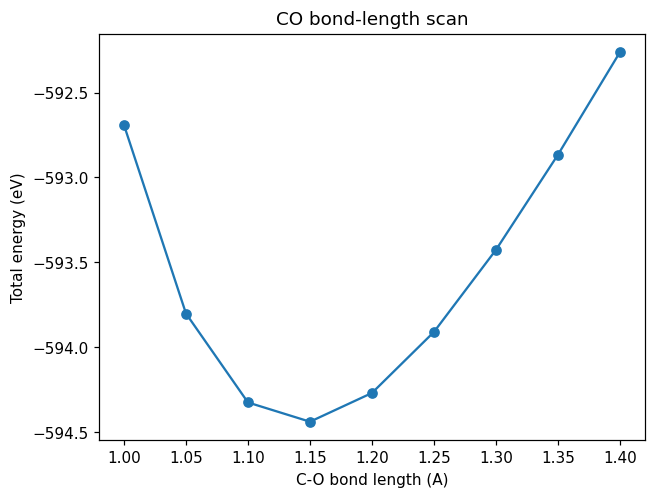

In [ ]:
plt.plot(bond_lengths, co_energies, 'o-')
plt.xlabel('C-O bond length (A)')
plt.ylabel('Total energy (eV)')
plt.title('CO bond-length scan')
plt.show()


In [ ]:
# Fit a parabola near the minimum: E(d) ~ E0 + 0.5*k*(d-d0)^2
coeffs = np.polyfit(bond_lengths, co_energies, 2)   # [a, b, c] for a*d^2+b*d+c
a, b, c = coeffs
d0 = -b / (2 * a)          # vertex of the parabola = equilibrium bond length
k_eV_per_A2 = 2 * a        # curvature -> force constant
print(f'Equilibrium bond length: {d0:.3f} A   (experiment: 1.128 A)')

# Convert the force constant to a vibrational wavenumber using the
# reduced mass of C-O and standard unit conversions.
import scipy.constants as sc
k_SI = k_eV_per_A2 * sc.e * 1e20               # eV/A^2 -> J/m^2
mu = (12.000 * 15.999) / (12.000 + 15.999) * sc.atomic_mass  # reduced mass, kg
omega = np.sqrt(k_SI / mu)                      # rad/s
wavenumber = omega / (2 * np.pi * sc.c) / 100    # -> cm^-1
print(f'Estimated vibrational wavenumber: {wavenumber:.0f} cm^-1  '
      f'(experiment: 2143 cm^-1)')


Equilibrium bond length: 1.175 A   (experiment: 1.128 A)
Estimated vibrational wavenumber: 1889 cm^-1  (experiment: 2143 cm^-1)


The harmonic estimate is not expected to match the experimental 2143 cm⁻¹ exactly.

## Part 3 — Kohn–Sham energy levels: the HOMO–LUMO gap of CO

At the equilibrium geometry, QE also reports the Kohn–Sham eigenvalues — the DFT analogue of molecular orbital energies. Let's plot them as a level diagram.

In [ ]:
n_electrons = 10  # C (4 valence) + O (6 valence) for these pseudopotentials
n_occ = n_electrons // 2

homo_lumo_data = dict(input_data)
homo_lumo_data['system'] = dict(input_data['system'])
homo_lumo_data['system']['nbnd'] = n_occ + 4

co_eq = make_boxed_molecule(['C', 'O'], [[0, 0, 0], [0, 0, d0]])
co_eq.calc = Espresso(profile=profile, pseudopotentials=pseudopotentials, input_data=homo_lumo_data,
                       kpts=(1, 1, 1))
co_eq.get_potential_energy()


-594.3827226193943

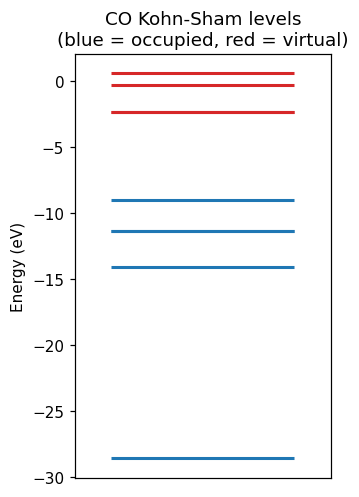

HOMO-LUMO gap: 6.67 eV


In [ ]:
eigs = co_eq.calc.get_eigenvalues(kpt=0, spin=0)  # eV

fig, ax = plt.subplots(figsize=(3, 5))
for i, e in enumerate(eigs[:n_occ + 4]):
    color = 'tab:blue' if i < n_occ else 'tab:red'
    ax.hlines(e, 0, 1, color=color, linewidth=2)
ax.set_xlim(-0.2, 1.2)
ax.set_xticks([])
ax.set_ylabel('Energy (eV)')
ax.set_title('CO Kohn-Sham levels\n(blue = occupied, red = virtual)')
plt.show()
print(f'HOMO-LUMO gap: {eigs[n_occ] - eigs[n_occ - 1]:.2f} eV')


## Part 4 — O₂: how many unpaired electrons?

You've likely drawn a Lewis structure for O₂ before, with every electron neatly paired. Let's use DFT to actually check that, the same way we'd check any other hypothesis: compute it, and see what comes out. We'll run O₂ two ways — once forcing a closed-shell (all-paired) solution, and once allowing the spins to separate — and compare.

In [ ]:
o2 = make_boxed_molecule(['O', 'O'], [[0, 0, 0], [0, 0, 1.21]])

# Run 1: no spin polarization allowed (forces a closed-shell solution)
input_data_nospin = dict(input_data)
input_data_nospin['system'] = dict(input_data['system'])
o2.calc = Espresso(profile=profile, pseudopotentials={'O': pseudo_filename('O')},
                    input_data=input_data_nospin, kpts=(1, 1, 1))
e_nospin = o2.get_potential_energy()
print(f'O2 energy, spin-restricted:  {e_nospin:.4f} eV')


O2 energy, spin-restricted:  -873.7387 eV


In [ ]:
from ase.visualize import view

view(o2, viewer='x3d')  # drag to rotate, scroll to zoom


In [ ]:
# Run 2: allow spin polarization, and tell QE directly how many unpaired
# electrons to use (tot_magnetization=2, matching O2's known triplet
# ground state). Note this is a stronger statement than Run 1's setup --
# we are not letting SCF discover the magnetization freely here, we are
# telling it what to converge to, and then checking that this configuration
# is indeed lower in energy than the closed-shell Run 1 result.
input_data_spin = dict(input_data)
input_data_spin['system'] = dict(input_data['system'])
input_data_spin['system']['nspin'] = 2
input_data_spin['system']['tot_magnetization'] = 2.0

o2_spin = make_boxed_molecule(['O', 'O'], [[0, 0, 0], [0, 0, 1.21]])
o2_spin.calc = Espresso(profile=profile, pseudopotentials={'O': pseudo_filename('O')},
                         input_data=input_data_spin, kpts=(1, 1, 1))
e_spin = o2_spin.get_potential_energy()


def read_total_magnetization(pwo_file='espresso.pwo'):
    with open(pwo_file) as f:
        lines = f.readlines()
    for line in reversed(lines):   # last occurrence = final converged value
        if 'total magnetization' in line:
            return float(line.split('=')[1].split('Bohr')[0].strip())
    raise RuntimeError(f"Couldn't find 'total magnetization' in {pwo_file}")

magmom = read_total_magnetization()

print(f'O2 energy, spin-polarized:   {e_spin:.4f} eV')
print(f'Energy lowering from allowing spin: {e_nospin - e_spin:.4f} eV')
print(f'Converged total magnetization: {magmom:.2f} Bohr magnetons '
      f'(2.0 means 2 unpaired electrons)')


O2 energy, spin-polarized:   -874.9353 eV
Energy lowering from allowing spin: 1.1966 eV
Converged total magnetization: 2.00 Bohr magnetons (2.0 would mean 2 unpaired electrons)


The Lewis structure you learned shows all of O₂'s electrons paired. What does the *calculated* magnetization tell you that a Lewis structure fundamentally can't? And now compare: what magnetization would you expect if you ran this same spin-polarized recipe on CO? Why?

## Discuss / Explain

Answer in your own words, using what you actually observed in this notebook's plots and computed numbers.

1. A 12 Å cubic box was used for both CO and O₂ without testing whether that's actually big enough. Propose a concrete experiment (using tools already in this notebook) that would tell you whether 12 Å is big enough, and explain what result would tell you it *isn't*.
2. The parabola that was fit to the CO bond-length scan is only a good approximation very close to the minimum. Looking at the E vs. bond-length plot, over roughly what range of bond lengths would you trust the parabolic fit, and where does it visibly start to break down? Why would a real (anharmonic) potential and a parabola necessarily disagree away from the minimum?
3. CO turned out to have zero net magnetization and O₂ has two unpaired electrons. Both are diatomic molecules with electrons filling the same general set of molecular orbitals. What's different about their electron counts or orbital energetics that explains why one pairs up completely and the other doesn't?


## Assignment Exercises

For the following molecular systems repeat Part 2 and Part 4 workflow (bond length scan, vibrational frequency estimate, and the closed-shell vs. spin-polarized magnetization check).

1. **N₂ and CO are isoelectronic** — same number of valence electrons, similar bonding picture. Compute N₂'s bond length and vibrational frequency and compare directly against your CO numbers. Are they as similar as the 'isoelectronic' label suggests they should be?
2. **Cl₂** — a much heavier diatomic molecule. How does its bond length and vibrational frequency compare to CO/N₂, and how much of that difference do you think comes from bond strength vs. simply the heavier reduced mass?
3. **F₂** — famously has a *weaker* bond than you might predict from fluorine's high electronegativity. Does your computed vibrational frequency support that?
4. **NO** — an odd-electron molecule (with 11 valence count). Run the same closed-shell-vs-spin-polarized comparison you did for O₂. What magnetization do you get, and how does NO's case differ from both CO (0 unpaired) and O₂ (2 unpaired)?


## Summary

You've now run real DFT calculations: located an equilibrium bond length by hand, connected a curvature to a vibrational frequency, looked at Kohn–Sham levels, and watched DFT reproduce O₂'s famous unpaired electrons.

## References

- Giannozzi, P. et al. *QUANTUM ESPRESSO: a modular and open-source software project for quantum simulations of materials*. J. Phys.: Condens. Matter 21, 395502 (2009); and later updates (2017, 2020). https://www.quantum-espresso.org
- Larsen, A. H. et al. *The Atomic Simulation Environment — a Python library for working with atoms*. J. Phys.: Condens. Matter 29, 273002 (2017). https://wiki.fysik.dtu.dk/ase/
- Garrity, K. F., Bennett, J. W., Rabe, K. M. & Vanderbilt, D. *Pseudopotentials for high-throughput DFT calculations*. Comput. Mater. Sci. 81, 446 (2014). https://www.physics.rutgers.edu/gbrv/
